PREDICTION DE SALAIRES - MARCHE DATA & IA


PARTIE ML :   EDA + Feauture Engineering + Modélisation

Maintenant que nous avons obtenu une base de données exploitable, nous allons pouvoir nous pencher sur la partie machine learning, à savoir prédire au maximum les salaires sur le marché de la DATA et de l'IA.
Nous  tenterons de prédire les salaires minimums et maximums ; nos deux variables cibles sont donc max_amount et min_amount

# IMPORTATION

Importation des différentes bibliothèques et définition de l'objet Spark

In [1]:

# --- 1. Moteur Spark  ---
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# --- 2. Feature Engineering version Spark ---
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

# --- 3. Modèles de Régression  ---
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor, LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder


# --- 4. Évaluation des performances ---
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Environnement Big Data prêt !")






✅ Environnement Big Data prêt !


In [2]:

# on définit l'objet 'spark'
spark = SparkSession.builder \
    .appName("Brahim_ML_Salary_Predictor") \
    .getOrCreate()

print(" La SparkSession est prête !")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/18 15:56:59 WARN Utils: Your hostname, codespaces-a314b8, resolves to a loopback address: 127.0.0.1; using 10.0.2.190 instead (on interface eth0)
26/04/18 15:56:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/18 15:57:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


 La SparkSession est prête !



# Chargement et Inspection  des Données

Il faudra faire attention à modifier le lien vers les données finales lors du chargement

In [3]:
# 1. Chargement des données réelles avec Spark

df = spark.read.parquet("../spark//final.parquet")
df_to_predict = spark.read.parquet("../spark/to_predict.parquet")

# 2. Affichage des statistiques 

num_rows = df.count()
num_cols = len(df.columns)

print(f"✅ Dataset final chargé : {num_rows} lignes × {num_cols} colonnes")
print(f"✅ Dataset à prédire chargé : {df_to_predict.count()} lignes")

# 3. Inspection des colonnes et types 
print(" Schéma des données (Types Spark) :")
df.printSchema()

✅ Dataset final chargé : 2945 lignes × 11 colonnes
✅ Dataset à prédire chargé : 157 lignes
 Schéma des données (Types Spark) :
root
 |-- description: string (nullable = true)
 |-- company: string (nullable = true)
 |-- company_industry: string (nullable = true)
 |-- date_posted: string (nullable = true)
 |-- title: string (nullable = true)
 |-- location: string (nullable = true)
 |-- max_amount: double (nullable = true)
 |-- min_amount: double (nullable = true)
 |-- job_type_clean: string (nullable = true)
 |-- contract_type: string (nullable = true)
 |-- work_time: string (nullable = true)



In [4]:
# Aperçu des premières lignes
df.limit(5).toPandas()

,description,company,company_industry,date_posted,title,location,max_amount,min_amount,job_type_clean,contract_type,work_time
0,"IT'S A W2 CONTRACT ROLE, NO C2C/1099 Title: ...","iSpace, Inc",IT Jobs,2026-03-30,Data Engineer/Analyst,"Marysville, Union County",127720.17,127720.17,,Unknown,Unknown
1,Join the Future of Commerce with Whatnot! Wha...,Whatnot,IT Jobs,2026-03-04,Data Engineer,"San Francisco, California",260000.00,180000.00,fulltime,Unknown,Full-time
2,P&C Insurance Experience Is Required For This...,Mission Underwriting Managers,IT Jobs,2026-04-11,Senior Data Engineer,US,127209.50,127209.50,fulltime,Unknown,Full-time
3,"$50-$55 per hour Fort Worth, TX Contract Job L...",US Tech Solutions,IT Jobs,2026-02-05,Sr. Data Engineer,"Fort Worth, Tarrant County",140387.60,140387.60,,Unknown,Unknown
4,**About Carrier**\n\n\nCarrier Global Corporat...,Carrier,Unknown,2026-04-10T00:00:00.000,Senior Mechanical Systems Engineer – Data Cent...,"Charlotte, NC, US",158000.00,79000.00,fulltime,Unknown,Full-time


En observant les premières lignes, nous arrivons très vite à la conclusion qu'il faudra travailler les différentes variables (notamment lors de la partie Feature engineering). Par exemple, entre les différentes job_type_clean, contract_type et work_time, il serait intéressant de choisir l'une d'entre elles (la plus propre) sachant qu'elles contiennent la même information.

In [5]:

# 1. Comptage des nulls (Ta logique est parfaite ici)
df_nulls = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])

print("📊 Valeurs nulles par colonne :")
df_nulls.show()

print(f"Nombre de lignes avant nettoyage : {df.count()}")

📊 Valeurs nulles par colonne :
+-----------+-------+----------------+-----------+-----+--------+----------+----------+--------------+-------------+---------+
|description|company|company_industry|date_posted|title|location|max_amount|min_amount|job_type_clean|contract_type|work_time|
+-----------+-------+----------------+-----------+-----+--------+----------+----------+--------------+-------------+---------+
|          0|      0|               0|          0|    0|       0|         1|         0|             0|            0|        0|
+-----------+-------+----------------+-----------+-----+--------+----------+----------+--------------+-------------+---------+

Nombre de lignes avant nettoyage : 2945


Globalement, notre base de données est propre. Toutefois, on remarque quelques incohérences. Par exemple, on remarque qu'il n'y a aucune valeur manquante pour job_type_clean alors que l'on retrouve bien des cases vides. Cela signifie, comme on le remarque ci-dessous, que cette variable prend en compte le vide ('') comme modalité.

In [6]:

# 1. Identifier les colonnes textuelles (String) sauf la description

string_cols = [c for c, t in df.dtypes if t == "string" and c != "description"]

print(f" Analyse des {len(string_cols)} variables catégorielles :\n")

for col_name in string_cols:
    # A. Nombre de valeurs distinctes 
    distinct_count = df.select(col_name).distinct().count()
    
    # B. Récupération des modalités (Logique du TP 3, section 2)
    # On trie pour que l'affichage soit propre
    modalities_rows = df.select(col_name).distinct().orderBy(col_name).collect()
    modalities = [row[0] for row in modalities_rows]
    
    # C. Affichage des résultats
    print(f"Variable : **{col_name}**")
    print(f"  - Nombre de modalités : {distinct_count}")
    print(f"  - Liste des valeurs : {modalities}")
    print("-" * 50)

 Analyse des 8 variables catégorielles :

Variable : **company**
  - Nombre de modalités : 1665
  - Liste des valeurs : ['. Crane Worldwide Logistics .', '3Md Inc.', '4P Consulting', '8451', '8am', '@Orchard', 'AAA Northeast', 'ACI Infotech', 'ACV', 'ADTM Adenza Technology de Mexico S de RL de CV', 'AEP Kimco Realty Corporation & Subsidiaries', 'AERMOR LLC', 'AES Corporation', 'AGM Tech Solutions, LLC', 'AIT Global, Inc.', 'ALL REALTRUCK Career', 'AMEND Consulting', 'AMH', 'AMS Networks', 'ARAMARK', 'ARKA Group LP', 'AST SpaceMobile', 'AVIAN, LLC', 'AaraTechnologies Inc', 'Abaka AI', 'AbbVie', 'Abbott', 'Aberdeen Proving Ground', 'Above Lending', 'Abridge', 'Acadian Asset Management', 'Accelerant', 'Accenture', 'Accenture Federal Services', 'Ace Technologies, Inc.', 'Acosta', 'Acosta Group', 'Actify Systems LLC', 'Acuity', 'AcuityMD', 'Acunor Infotech', 'AdCellerant', 'Adaptive Home Health / Fira Health', 'Adelante Healthcare', 'Aderant North America', 'Adidev Technologies', 'Aditi Con

Face au nombre important de modalités pour certaines variables, nous les regrouperons sous certaines catégories dans une première partie Feature engineering.

# Fearture Engineering

In [7]:

# On crée des regroupements logiques à partir des 31 modalités existantes
df_refined = df.withColumn("industry_group", 
    F.when(F.col("company_industry").isin("IT Jobs", "Internet And Software", "Computers And Electronics"), "Tech/IT")
    .when(F.col("company_industry").isin("Banks And Financial Services", "Accounting & Finance Jobs"), "Finance")
    .when(F.col("company_industry").isin("Health Care", "Healthcare & Nursing Jobs", "Pharmaceuticals"), "Health/Pharma")
    .when(F.col("company_industry").isin("Engineering Jobs", "Industrial Manufacturing", "Manufacturing Jobs", "Energy, Oil & Gas Jobs"), "Industry/Eng")
    .when(F.col("company_industry").isin("Government", "Education And Schools", "Teaching Jobs"), "Public/Education")
    .otherwise("Other/Services") # Pour le reste : Real Estate, Logistics, Unknown, etc.
)

# On vérifie la répartition 
print(" Répartition de tes nouveaux pôles sectoriels :")
df_refined.groupBy("industry_group").count().orderBy(F.desc("count")).show()

 Répartition de tes nouveaux pôles sectoriels :
+----------------+-----+
|  industry_group|count|
+----------------+-----+
|         Tech/IT| 2441|
|  Other/Services|  258|
|    Industry/Eng|  213|
|   Health/Pharma|   14|
|         Finance|   11|
|Public/Education|    8|
+----------------+-----+



In [8]:

df_refined = df_refined.withColumn("job_role", 
    F.when(F.lower(F.col("title")).contains("scientist"), "Data Scientist")
    .when(F.lower(F.col("title")).contains("engineer"), "Data Engineer")
    .when(F.lower(F.col("title")).contains("analyst"), "Data Analyst")
    .when(F.lower(F.col("title")).contains("ai") | F.lower(F.col("title")).contains("ml"), "AI/ML Specialist")
    .when(F.lower(F.col("title")).contains("manager") | F.lower(F.col("title")).contains("director"), "Management")
    .otherwise("Other Tech")
)

# On vérifie la nouvelle répartition 
df_refined.groupBy("job_role").count().orderBy(F.desc("count")).show()

+----------------+-----+
|        job_role|count|
+----------------+-----+
|   Data Engineer| 2794|
|  Data Scientist|   51|
|AI/ML Specialist|   39|
|    Data Analyst|   36|
|      Other Tech|   17|
|      Management|    8|
+----------------+-----+



In [9]:

# On crée la colonne seniority_level en cherchant des mots-clés dans le titre
df_refined = df_refined.withColumn("seniority_level", 
    F.when(F.lower(F.col("title")).contains("senior") | F.lower(F.col("title")).contains("sr"), "Senior")
    .when(F.lower(F.col("title")).contains("lead") | F.lower(F.col("title")).contains("principal") | F.lower(F.col("title")).contains("staff"), "Lead/Principal")
    .when(F.lower(F.col("title")).contains("junior") | F.lower(F.col("title")).contains("jr") | F.lower(F.col("title")).contains("intern") | F.lower(F.col("title")).contains("associate"), "Junior/Entry")
    .when(F.lower(F.col("title")).contains("director") | F.lower(F.col("title")).contains("vp") | F.lower(F.col("title")).contains("head"), "Leadership")
    .otherwise("Mid-level/Other")
)

# On vérifie la répartition 
print(" Répartition par niveau de séniorité :")
df_refined.groupBy("seniority_level").count().orderBy(F.desc("count")).show()

 Répartition par niveau de séniorité :
+---------------+-----+
|seniority_level|count|
+---------------+-----+
|Mid-level/Other| 1696|
|         Senior|  801|
| Lead/Principal|  337|
|   Junior/Entry|   74|
|     Leadership|   37|
+---------------+-----+



In [10]:
# On extrait les 4 premiers caractères pour avoir l'année 
df_refined = df_refined.withColumn("posted_year", F.substring(F.col("date_posted"), 1, 4).cast("int"))

# On vérifie si tu as plusieurs années différentes
df_refined.groupBy("posted_year").count().orderBy("posted_year").show()

+-----------+-----+
|posted_year|count|
+-----------+-----+
|       2022|    2|
|       2023|    1|
|       2024|   49|
|       2025|  319|
|       2026| 2574|
+-----------+-----+



In [11]:

# 1. On prépare le split
split_loc = F.split(F.col("location"), ",")

# 2. On extrait avec vérification de la taille 
# size(split_loc) > 1 garantit qu'il y a au moins une virgule
df_refined = df_refined.withColumn("city", F.trim(split_loc.getItem(0))) \
                       .withColumn("state", 
                            F.when(F.size(split_loc) > 1, F.trim(split_loc.getItem(1)))
                            .otherwise("Unknown")
                        )

# 3. On affine l'état (Certains ont "US" après la 2ème virgule)
# On s'assure que c'est bien un code à 2 lettres (ex: CA, NY, TX)
df_refined = df_refined.withColumn("state_clean", 
    F.when(F.length(F.col("state")) == 2, F.col("state"))
    .otherwise("Other/Remote")
)

# 4. Nettoyage final des colonnes de travail
df_refined = df_refined.drop("state") # On garde state_clean et city

print(" Extraction sécurisée terminée !")
df_refined.select("location", "city", "state_clean").show(20, truncate=False)

 Extraction sécurisée terminée !
+--------------------------+-------------+------------+
|location                  |city         |state_clean |
+--------------------------+-------------+------------+
|Marysville, Union County  |Marysville   |Other/Remote|
|San Francisco, California |San Francisco|Other/Remote|
|US                        |US           |Other/Remote|
|Fort Worth, Tarrant County|Fort Worth   |Other/Remote|
|Charlotte, NC, US         |Charlotte    |NC          |
|Charlotte, NC, US         |Charlotte    |NC          |
|Chicago, IL, US           |Chicago      |IL          |
|Ann Arbor, MI, US         |Ann Arbor    |MI          |
|Atlanta, GA, US           |Atlanta      |GA          |
|Raleigh, NC, US           |Raleigh      |NC          |
|Nashville, TN, US         |Nashville    |TN          |
|Denver, CO, US            |Denver       |CO          |
|San Diego, CA, US         |San Diego    |CA          |
|San Diego, CA, US         |San Diego    |CA          |
|San Diego, CA,

Ci-dessous , on essaye de voir si on peut tirer plus  d'informations sur la variable description

In [12]:
# 1. On sélectionne la colonne et on limite à 5 
# 2. On utilise .collect() pour transformer cela en liste Python 
descriptions_completes = df_refined.select("description").limit(5).collect()

print(" AFFICHAGE INTÉGRAL DES 5 PREMIÈRES DESCRIPTIONS\n")
print("="*60)

for i, ligne in enumerate(descriptions_completes):
    print(f"\n📍 DESCRIPTION N°{i+1} :")
    print("-" * 30)
    # ligne[0] récupère le contenu de la première (et seule) colonne sélectionnée
    print(ligne[0]) 
    print("\n" + "="*60)

 AFFICHAGE INTÉGRAL DES 5 PREMIÈRES DESCRIPTIONS


📍 DESCRIPTION N°1 :
------------------------------
 IT'S A W2 CONTRACT ROLE, NO C2C/1099  Title: Data Analyst / Engineer Location: Raymond, OH (Hybrid 4 days/week onsite and 1 day/week remote) Contract Duration: 14 months Rate: $57/hr on W2 What will this person be working on In this role, person will be responsible for conducting data analysis to support decision-making processes within the organization. The ideal candidate will have a strong analytical mindset, excellent communication skills, and the ability to work collaboratively with cross…


📍 DESCRIPTION N°2 :
------------------------------
 Join the Future of Commerce with Whatnot! Whatnot is the largest livestream shopping platform in North America and Europe to buy, sell, and discover the things you love. Whether it's trading cards, fashion, electronics, or live plants, our sellers are building real businesses across hundreds of categories. We're building live commerce at a s

On supprime les anciennes colonnes et on laisse les nouvelles 

In [13]:
# 1. On définit la liste des colonnes à supprimer 
cols_to_drop = [
    "description",
    "company", 
    "company_industry", 
    "date_posted", 
    "location", 
    "title", 
    "job_type_clean", 
    "contract_type", 
    "state_temp" 
]

# 2. On crée le DataFrame final
df_final = df_refined.drop(*cols_to_drop)

# 3. Vérification visuelle
print(" Le dataset final est prêt avec  !")
df_final.printSchema()

 Le dataset final est prêt avec  !
root
 |-- max_amount: double (nullable = true)
 |-- min_amount: double (nullable = true)
 |-- work_time: string (nullable = true)
 |-- industry_group: string (nullable = false)
 |-- job_role: string (nullable = false)
 |-- seniority_level: string (nullable = false)
 |-- posted_year: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- state_clean: string (nullable = true)



# EDA - Exploration des Données 

Nous analysons notre nouvelle base de données

In [14]:
df_final.limit(5).toPandas()

,max_amount,min_amount,work_time,industry_group,job_role,seniority_level,posted_year,city,state_clean
0,127720.17,127720.17,Unknown,Tech/IT,Data Engineer,Mid-level/Other,2026,Marysville,Other/Remote
1,260000.00,180000.00,Full-time,Tech/IT,Data Engineer,Mid-level/Other,2026,San Francisco,Other/Remote
2,127209.50,127209.50,Full-time,Tech/IT,Data Engineer,Senior,2026,US,Other/Remote
3,140387.60,140387.60,Unknown,Tech/IT,Data Engineer,Senior,2026,Fort Worth,Other/Remote
4,158000.00,79000.00,Full-time,Other/Services,Data Engineer,Senior,2026,Charlotte,NC


In [15]:

# 1. Calcul des agrégations pour les deux colonnes
stats = df_final.select(
    F.percentile_approx("min_amount", 0.5).alias("med_min"),
    F.mean("min_amount").alias("avg_min"),
    F.min("min_amount").alias("min_min"),
    F.max("min_amount").alias("max_min"),
    F.percentile_approx("max_amount", 0.5).alias("med_max"),
    F.mean("max_amount").alias("avg_max"),
    F.min("max_amount").alias("min_max"),
    F.max("max_amount").alias("max_max")
).collect()[0] # On récupère la première (et seule) ligne de résultat

# 2. Affichage propre pour le salaire MINIMUM
print(f" Distribution du salaire MINIMUM :")
print(f"   Médiane : ${stats['med_min']:,.0f}")
print(f"   Moyenne : ${stats['avg_min']:,.0f}")
print(f"   Min     : ${stats['min_min']:,.0f}")
print(f"   Max     : ${stats['max_min']:,.0f}")

# 3. Affichage propre pour le salaire MAXIMUM
print(f"\n Distribution du salaire MAXIMUM :")
print(f"   Médiane : ${stats['med_max']:,.0f}")
print(f"   Moyenne : ${stats['avg_max']:,.0f}")
print(f"   Min     : ${stats['min_max']:,.0f}")
print(f"   Max     : ${stats['max_max']:,.0f}")

 Distribution du salaire MINIMUM :
   Médiane : $129,210
   Moyenne : $135,014
   Min     : $1
   Max     : $452,873

 Distribution du salaire MAXIMUM :
   Médiane : $141,160
   Moyenne : $150,399
   Min     : $33,881
   Max     : $500,000


On remarque ici une valeur aberrante ( le min = 1 pour minimum), on s'occupera par la suite de mettre une condition sur cette variable

In [16]:

# 1. Calcul des statistiques de base
total_count = df_final.count()
features = ["industry_group", "job_role", "seniority_level", "work_time", "posted_year", "state_clean", "city"]

print(f" RAPPORT QUALITÉ DONNÉES - {total_count} lignes au total")
print("-" * 50)

# 2. Taux de remplissage (Null Check)
null_stats = df_final.select([
    (F.count(F.when(F.col(c).isNotNull(), c)) / total_count * 100).alias(c)
    for c in (["min_amount", "max_amount"] + features)
])

print("\n Taux de remplissage (% de données renseignées) :")
null_stats.show()

# 3. Distribution des targets (Min & Max)
print(" Distribution des salaires cibles :")
df_final.select("min_amount", "max_amount").summary("min", "25%", "50%", "75%", "max", "mean").show()

# 4. Cardinalité (Diversité des catégories)
print(" Diversité des données :")
cardinality = df_final.select(
    F.countDistinct("city").alias("Villes distinctes"),
    F.countDistinct("state_clean").alias("États distinctes"),
    # Note : 'company' a été supprimé de ton df_final, on regarde donc les autres
    F.countDistinct("job_role").alias("Métiers distincts")
)
cardinality.show()

# 5. CONTRÔLE LOGIQUE (Le "Peer Check")
logical_errors = df_final.filter(F.col("min_amount") > F.col("max_amount")).count()
zero_salaries = df_final.filter((F.col("min_amount") <= 0) | (F.col("max_amount") <= 0)).count()

print(f" ALERTES QUALITÉ :")
print(f"   - Annonces avec Min > Max : {logical_errors}")
print(f"   - Annonces avec salaire <= 0 : {zero_salaries}")

if logical_errors == 0 and zero_salaries == 0:
    print(" Données saines pour la modélisation.")
else:
    print(" Attention : Des lignes erronées ont été détectées.")

 RAPPORT QUALITÉ DONNÉES - 2945 lignes au total
--------------------------------------------------

 Taux de remplissage (% de données renseignées) :
+----------+-----------------+--------------+--------+---------------+---------+-----------+-----------+-----+
|min_amount|       max_amount|industry_group|job_role|seniority_level|work_time|posted_year|state_clean| city|
+----------+-----------------+--------------+--------+---------------+---------+-----------+-----------+-----+
|     100.0|99.96604414261459|         100.0|   100.0|          100.0|    100.0|      100.0|      100.0|100.0|
+----------+-----------------+--------------+--------+---------------+---------+-----------+-----------+-----+

 Distribution des salaires cibles :
+-------+------------------+------------------+
|summary|        min_amount|        max_amount|
+-------+------------------+------------------+
|    min|               1.0|          33881.36|
|    25%|         104880.16|         113738.46|
|    50%|         

Ici, on applique un seuil de 30 000 pour les salaires minimums 

In [17]:

# Choix du seuil expert
seuil_expert = 30000

# 1. On filtre
df_final = df_final.filter(F.col("min_amount") >= seuil_expert)

# 2. On vérifie l'impact
print(f" Nettoyage 'Market-Ready' effectué !")
print(f" Seuil appliqué : {seuil_expert:,.0f} $")
print(f" Nombre de lignes finales pour l'IA : {df_final.count()}")

# 3. Un petit coup d'oeil sur les stats
df_final.select("min_amount", "max_amount").summary("min", "mean", "50%").show()

 Nettoyage 'Market-Ready' effectué !
 Seuil appliqué : 30,000 $
 Nombre de lignes finales pour l'IA : 2943
+-------+------------------+-----------------+
|summary|        min_amount|       max_amount|
+-------+------------------+-----------------+
|    min|          33881.36|         33881.36|
|   mean|135100.43487597693|150391.0131974177|
|    50%|         129211.03|         141160.2|
+-------+------------------+-----------------+



## Graphique 

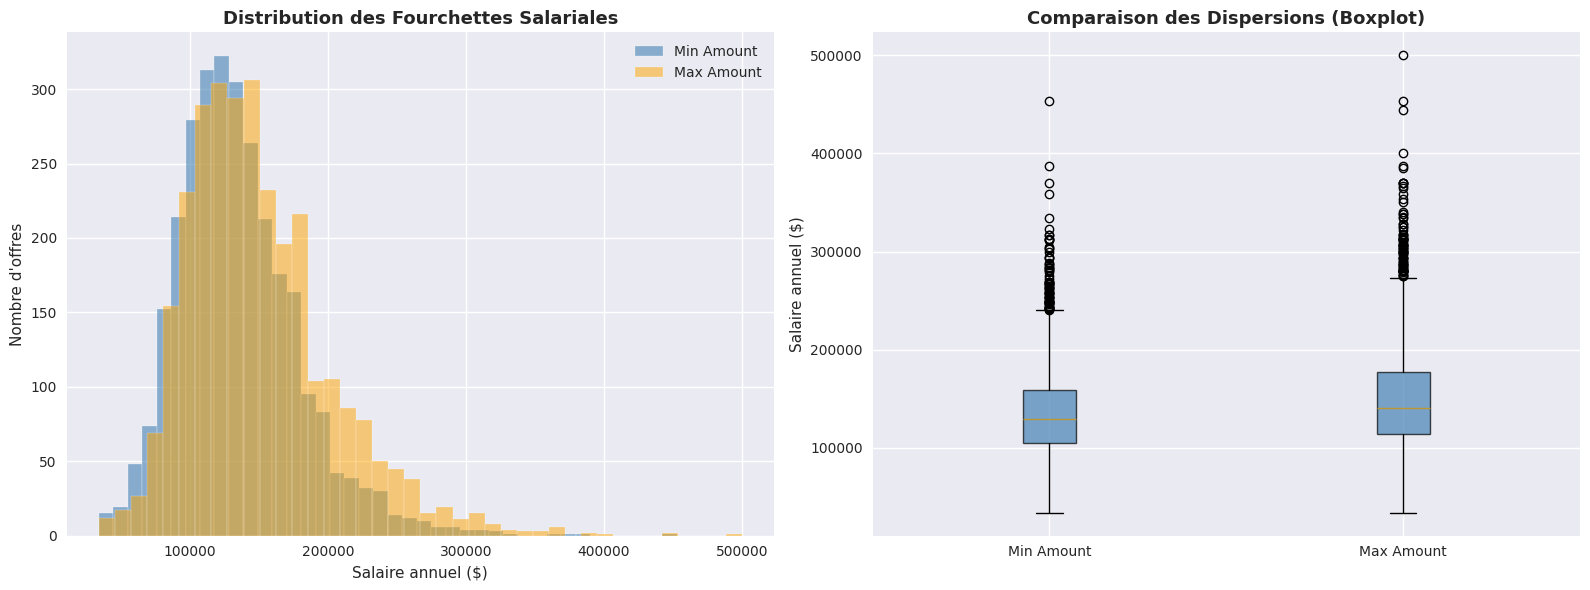

In [18]:

# 1. On convertit uniquement les colonnes nécessaires en Pandas
# C'est plus léger que de convertir tout le DataFrame
pdf = df_final.select("min_amount", "max_amount").toPandas()

# 2. Configuration des graphiques (on affiche les deux targets !)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramme comparatif
axes[0].hist(pdf['min_amount'], bins=40, color='steelblue', alpha=0.6, label='Min Amount', edgecolor='white')
axes[0].hist(pdf['max_amount'], bins=40, color='orange', alpha=0.5, label='Max Amount', edgecolor='white')
axes[0].set_title('Distribution des Fourchettes Salariales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Salaire annuel ($)')
axes[0].set_ylabel('Nombre d\'offres')
axes[0].legend()

# Boxplot pour voir les outliers sur les deux cibles
axes[1].boxplot([pdf['min_amount'], pdf['max_amount']], labels=['Min Amount', 'Max Amount'], 
               patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Comparaison des Dispersions (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Salaire annuel ($)')

plt.tight_layout()
plt.show()

L'analyse visuelle des salaires révèle une distribution typiquement log-normale, caractérisée par une forte concentration des offres entre 100 000 et 160 000 dollars et une asymétrie marquée vers les hautes valeurs. Le diagramme en boîtes confirme cette tendance en mettant en évidence une multitude de valeurs atypiques (outliers) au-delà de 280 000 dollars, particulièrement pour le salaire maximum. Cette dispersion suggère que si le cœur du marché est homogène, les rémunérations exceptionnelles dépendent de facteurs plus complexes que la seule localisation géographique ou l'intitulé du poste, ce qui constituera un défi majeur pour la phase de modélisation prédictive.

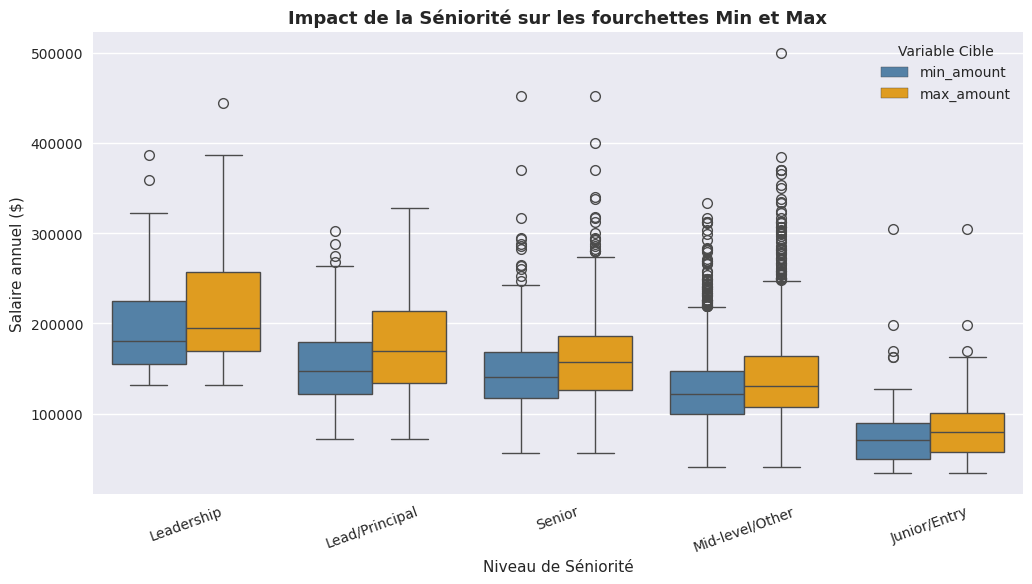


 Statistiques salariales par niveau de séniorité :
                 median_min  mean_min  median_max  mean_max  nb_offres
seniority_level                                                       
Leadership         180000.0  198538.0    195274.0  223539.0         37
Lead/Principal     147000.0  153338.0    169916.0  175337.0        337
Senior             140800.0  145077.0    156961.0  162410.0        799
Mid-level/Other    121298.0  127799.0    130439.0  140942.0       1696
Junior/Entry        70000.0   79939.0     78788.0   86989.0         74


In [19]:


# 1. Agrégation avec Spark : Calcul des stats pour les deux cibles
stats_spark = df_final.groupBy("seniority_level").agg(
    F.percentile_approx("min_amount", 0.5).alias("median_min"),
    F.mean("min_amount").alias("mean_min"),
    F.percentile_approx("max_amount", 0.5).alias("median_max"),
    F.mean("max_amount").alias("mean_max"),
    F.count("*").alias("nb_offres")
).orderBy(F.desc("median_max"))

# Conversion en Pandas pour l'affichage et le tri du graphique
pdf_stats = stats_spark.toPandas()

# 2. Préparation des données pour le Boxplot (on récupère un échantillon pour le graphique)
# On "fond" (melt) les colonnes min et max pour pouvoir les comparer sur le même axe Y
pdf_plot = df_final.select("seniority_level", "min_amount", "max_amount").toPandas()
pdf_melted = pdf_plot.melt(id_vars=['seniority_level'], 
                          value_vars=['min_amount', 'max_amount'], 
                          var_name='Type_Salaire', value_name='Salaire')

# 3. Graphique
fig, ax = plt.subplots(figsize=(12, 6))

# On définit l'ordre basé sur la médiane du salaire Max
order = pdf_stats['seniority_level'].tolist()

sns.boxplot(data=pdf_melted, x='seniority_level', y='Salaire', hue='Type_Salaire', 
            order=order, ax=ax, palette={'min_amount': 'steelblue', 'max_amount': 'orange'})

ax.set_title('Impact de la Séniorité sur les fourchettes Min et Max', fontsize=13, fontweight='bold')
ax.set_xlabel('Niveau de Séniorité')
ax.set_ylabel('Salaire annuel ($)')
plt.xticks(rotation=20)
plt.legend(title="Variable Cible")

plt.show()

# 4. Tableau récapitulatif 
print("\n Statistiques salariales par niveau de séniorité :")
print(pdf_stats.set_index('seniority_level').round(0))

Ce graphique met en évidence une hiérarchie salariale marquée, où la rémunération médiane progresse de manière constante suivant le niveau de responsabilités, des profils juniors jusqu'au leadership. On remarque cependant que la variabilité des salaires s'accroît fortement avec l'expérience, comme en témoigne la multiplication des valeurs atypiques pour les catégories "Senior" et "Mid-level". Cette dispersion suggère que pour les échelons supérieurs, l'intitulé de poste seul ne suffit plus à définir la fourchette salariale, laissant place à une influence accrue d'autres facteurs tels que la localisation géographique ou la rareté de l'expertise technique.

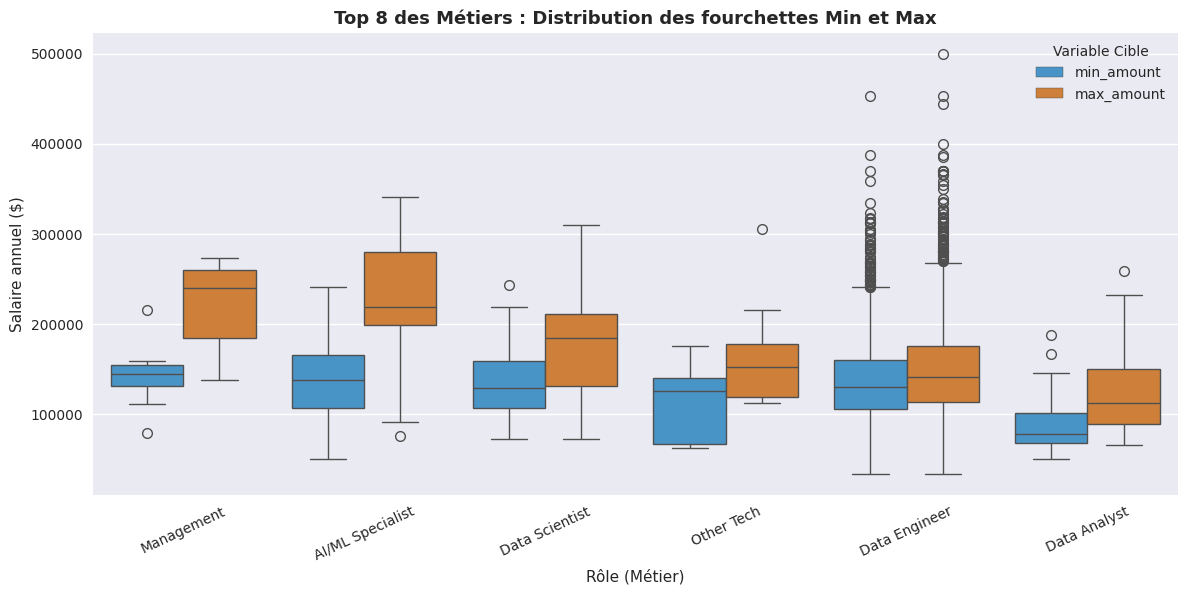

In [20]:


# 1. Identifier les 8 métiers (job_role) les plus fréquents avec Spark
top_roles_list = df_final.groupBy("job_role") \
    .count() \
    .orderBy(F.desc("count")) \
    .limit(8) \
    .select("job_role") \
    .rdd.flatMap(lambda x: x).collect()

# 2. Filtrer le DataFrame et passer en Pandas pour le graphique
# On ne garde que les lignes faisant partie du Top 8
pdf_roles = df_final.filter(F.col("job_role").isin(top_roles_list)) \
    .select("job_role", "min_amount", "max_amount") \
    .toPandas()

# 3. "Melter" les données pour afficher Min et Max côte à côte
pdf_melted = pdf_roles.melt(id_vars=['job_role'], 
                           value_vars=['min_amount', 'max_amount'], 
                           var_name='Type_Salaire', value_name='Salaire')

# 4. Création du graphique
fig, ax = plt.subplots(figsize=(14, 6))

# Calcul de l'ordre (basé sur la médiane du salaire Max)
order = pdf_roles.groupby('job_role')['max_amount'].median().sort_values(ascending=False).index

sns.boxplot(data=pdf_melted, x='job_role', y='Salaire', hue='Type_Salaire', 
            order=order, ax=ax, palette={'min_amount': '#3498db', 'max_amount': '#e67e22'})

ax.set_title('Top 8 des Métiers : Distribution des fourchettes Min et Max', fontsize=13, fontweight='bold')
ax.set_xlabel('Rôle (Métier)')
ax.set_ylabel('Salaire annuel ($)')
plt.xticks(rotation=25)
plt.legend(title="Variable Cible")

plt.show()

Cette analyse par métier souligne une hiérarchie salariale claire où les rôles de Management et de AI/ML Specialist dominent le marché avec des médianes nettement plus élevées, dépassant souvent les 200 000 dollars pour les fourchettes hautes. À l'inverse, les postes de Data Analyst affichent les rémunérations les plus basses et les plus resserrées. Un point frappant concerne les Data Engineers, qui présentent une concentration exceptionnelle de valeurs atypiques grimpant jusqu'à 500 000 dollars ; cela suggère que si le salaire "standard" du métier est bien défini, certaines expertises spécifiques en infrastructure ou dans des secteurs de niche permettent d'atteindre des niveaux de rémunération hors normes. Cette hétérogénéité entre les intitulés de postes confirme que le rôle métier sera l'un des piliers de la modélisation, tout en révélant une volatilité importante pour les profils les plus techniques.

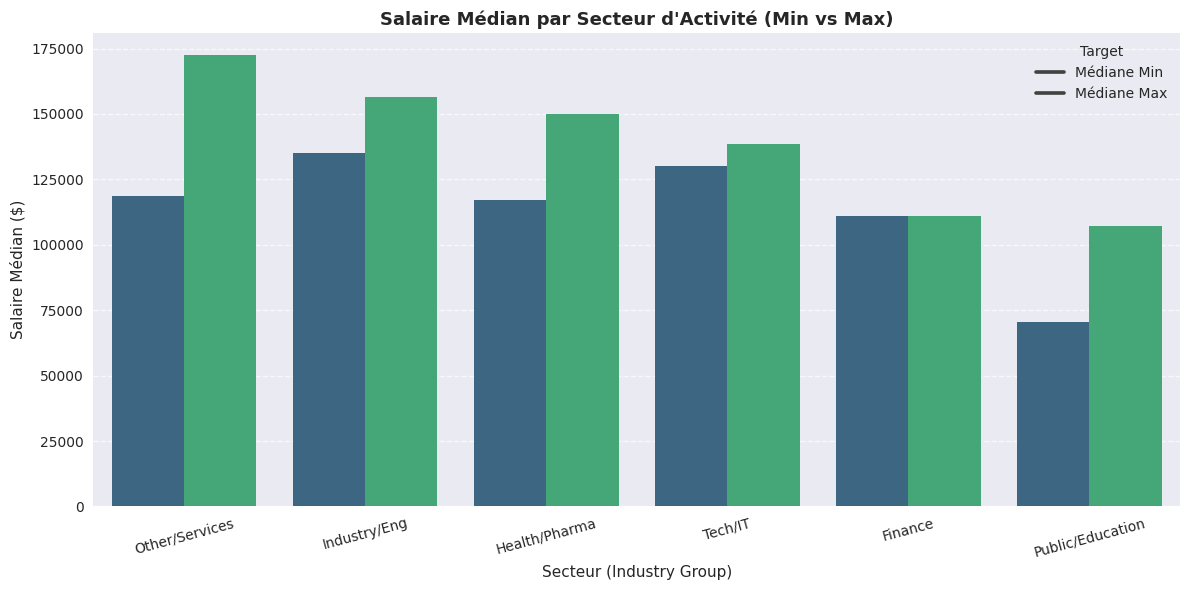

In [21]:


# 1. Agrégation Spark : Calcul des médianes pour les deux cibles par industrie
# On utilise percentile_approx pour la médiane, comme vu précédemment
industry_stats = df_final.groupBy("industry_group").agg(
    F.percentile_approx("min_amount", 0.5).alias("median_min"),
    F.percentile_approx("max_amount", 0.5).alias("median_max")
).toPandas()

# 2. Préparation pour Seaborn (Melt)
# On transforme pour avoir une colonne 'Type_Salaire' et une colonne 'Valeur'
df_plot = industry_stats.melt(id_vars=['industry_group'], 
                              value_vars=['median_min', 'median_max'], 
                              var_name='Type_Salaire', value_name='Salaire_Median')

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(12, 6))

# On définit l'ordre décroissant basé sur le salaire Max
order = industry_stats.sort_values('median_max', ascending=False)['industry_group']

sns.barplot(data=df_plot, x='industry_group', y='Salaire_Median', hue='Type_Salaire', 
            order=order, ax=ax, palette='viridis')

ax.set_title('Salaire Médian par Secteur d\'Activité (Min vs Max)', fontsize=13, fontweight='bold')
ax.set_xlabel('Secteur (Industry Group)')
ax.set_ylabel('Salaire Médian ($)')
plt.xticks(rotation=15)
plt.legend(title="Target", labels=['Médiane Min', 'Médiane Max'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Les secteurs des services, de l'industrie et de la santé affichent les salaires médians les plus élevés, contrastant avec un secteur public nettement moins rémunérateur. On note une rigidité salariale particulière en Finance, où les médianes min et max se confondent, tandis que les autres domaines présentent des fourchettes plus larges, suggérant une plus grande marge de négociation.

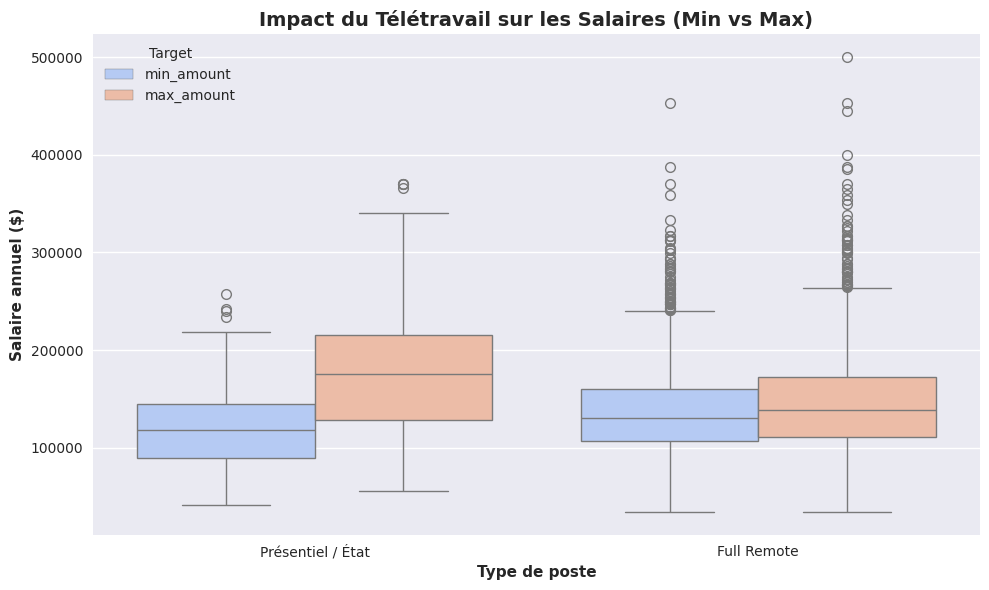

In [22]:
# 1. On crée la colonne 'is_remote'
df_plot = df_final.withColumn("is_remote", F.when(F.col("state_clean") == "Other/Remote", 1).otherwise(0))

# 2. Conversion sélective vers Pandas (on ne prend que le nécessaire pour ce plot)
pdf = df_plot.select("is_remote", "min_amount", "max_amount").toPandas()

# 3. Préparation du graphique unique
fig, ax = plt.subplots(figsize=(10, 6))

# --- GRAPHIQUE : Remote vs Présentiel (Boxplot Multi-Target) ---
# On "melt" pour voir le Min et le Max sur le même axe
pdf_melted = pdf.melt(id_vars=['is_remote'], value_vars=['min_amount', 'max_amount'], 
                      var_name='Target', value_name='Salaire')

sns.boxplot(data=pdf_melted, x='is_remote', y='Salaire', hue='Target', ax=ax, palette='coolwarm')

# Configuration des titres et labels
ax.set_title('Impact du Télétravail sur les Salaires (Min vs Max)', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Présentiel / État', 'Full Remote'])
ax.set_xlabel('Type de poste', fontweight='bold')
ax.set_ylabel('Salaire annuel ($)', fontweight='bold')

plt.tight_layout()
plt.show()

Cette comparaison montre que les postes en présentiel conservent des salaires médians légèrement plus élevés, suggérant une prime à la présence physique ou un alignement sur les coûts de la vie locaux. À l'inverse, le "Full Remote" se distingue par une volatilité extrême, illustrée par une concentration massive de valeurs atypiques grimpant jusqu'à 500 000 dollars. Cette disparité indique que si le télétravail peut offrir des rémunérations records pour certains experts hautement qualifiés, il présente également une base salariale plus hétérogène, ce qui compliquera la tâche du modèle pour prédire avec précision les revenus hors normes de cette catégorie.

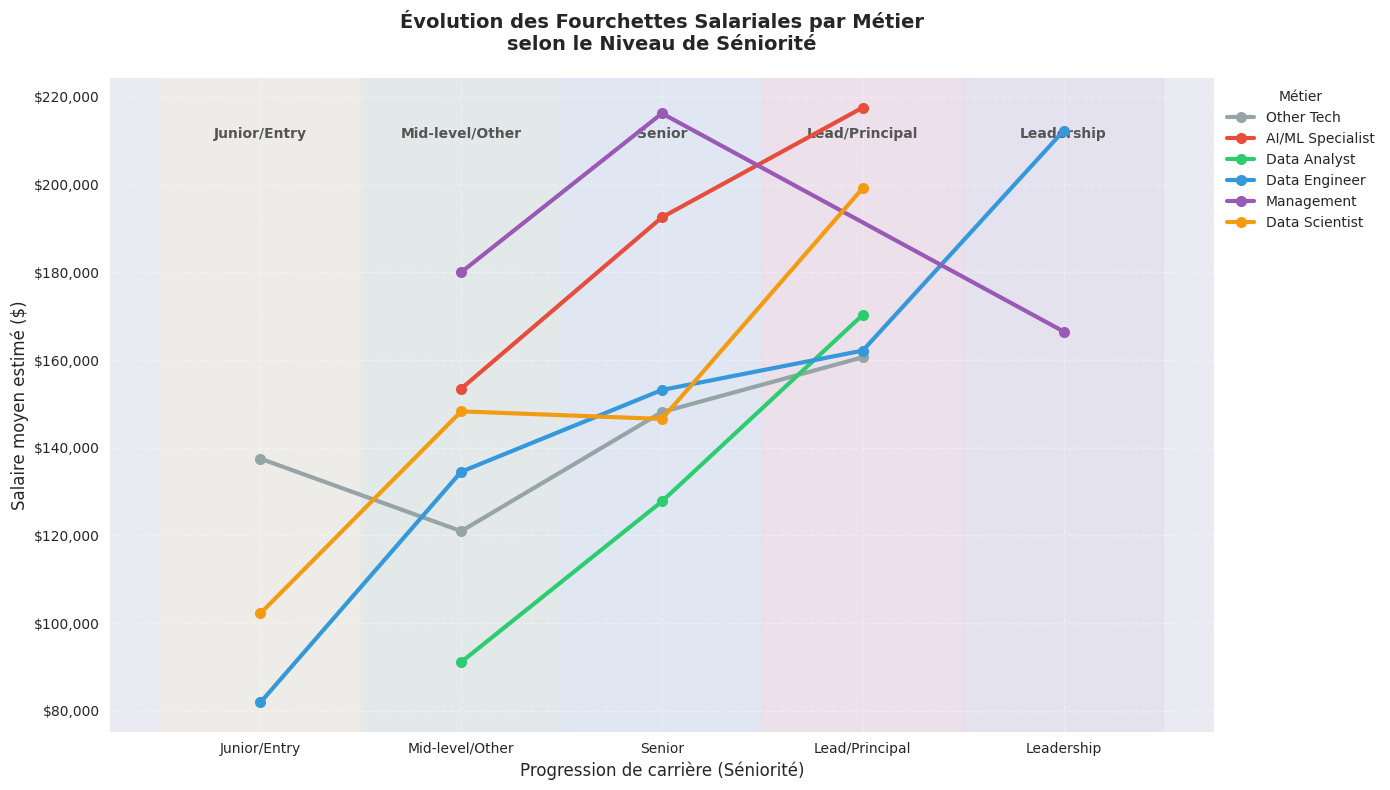

In [23]:

# 1. Préparation des données avec Spark
# On calcule le salaire moyen (milieu de fourchette) par rôle et par niveau
df_agg = df_final.groupBy("job_role", "seniority_level").agg(
    F.avg("min_amount").alias("avg_min"),
    F.avg("max_amount").alias("avg_max")
).withColumn("salary_avg", (F.col("avg_min") + F.col("avg_max")) / 2)

# Conversion en Pandas pour le graphique
pdf_plot = df_agg.toPandas()

# 2. Définition de l'ordre logique de la progression de carrière
seniority_order = ['Junior/Entry', 'Mid-level/Other', 'Senior', 'Lead/Principal', 'Leadership']

# On crée un dictionnaire de couleurs pour tes job_roles
colors = {
    'AI/ML Specialist': '#e74c3c',  # Rouge
    'Data Analyst': '#2ecc71',      # Vert
    'Data Scientist': '#f39c12',    # Orange
    'Data Engineer': '#3498db',     # Bleu
    'Management': '#9b59b6',        # Violet
    'Other Tech': '#95a5a6'         # Gris
}

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(14, 8))

# On trace une courbe pour chaque métier
for role in pdf_plot['job_role'].unique():
    subset = pdf_plot[pdf_plot['job_role'] == role].copy()
    
    # On s'assure que l'ordre est respecté pour que la ligne ne croise pas dans tous les sens
    subset['order'] = subset['seniority_level'].apply(lambda x: seniority_order.index(x) if x in seniority_order else 99)
    subset = subset.sort_values('order')
    
    # On ne trace que s'il y a plus d'un point
    if len(subset) > 1:
        ax.plot(subset['seniority_level'], subset['salary_avg'],
                color=colors.get(role, '#333'), marker='o', markersize=8,
                linewidth=3, label=role, zorder=5)

# 4. Ajout des zones de fond (Seniority Zones)
# Chaque catégorie devient une zone colorée
zone_colors = ['#fff9c4', '#c8e6c9', '#bbdefb', '#f8bbd0', '#d1c4e9']

for i, (label, color) in enumerate(zip(seniority_order, zone_colors)):
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.2, color=color, zorder=0)
    ax.text(i, ax.get_ylim()[1] * 0.95, label, 
            ha='center', va='top', fontsize=10, fontweight='bold', color='#555555')

# Configuration des axes
ax.set_xlabel("Progression de carrière (Séniorité)", fontsize=12)
ax.set_ylabel('Salaire moyen estimé ($)', fontsize=12)
ax.set_title("Évolution des Fourchettes Salariales par Métier\nselon le Niveau de Séniorité",
             fontsize=14, fontweight='bold', pad=20)

ax.legend(title='Métier', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

Ce graphique illustre une corrélation positive globale entre séniorité et salaire, marquée par l'ascension fulgurante des Data Engineers qui finissent par dominer le marché au stade Leadership. Les spécialités en AI/ML et Data Science suivent une progression constante et solide, confirmant que l'expertise technique pointue reste le moteur principal de la revalorisation salariale avec l'expérience.

On note toutefois une trajectoire atypique pour le Management, dont la courbe décline après le niveau Senior, ce qui peut refléter un effet de structure ou une limite de données pour les échelons les plus hauts. Globalement, ce visuel démontre que le métier choisi n'impacte pas seulement le salaire de départ, mais détermine surtout la pente et le plafond de la progression de carrière.

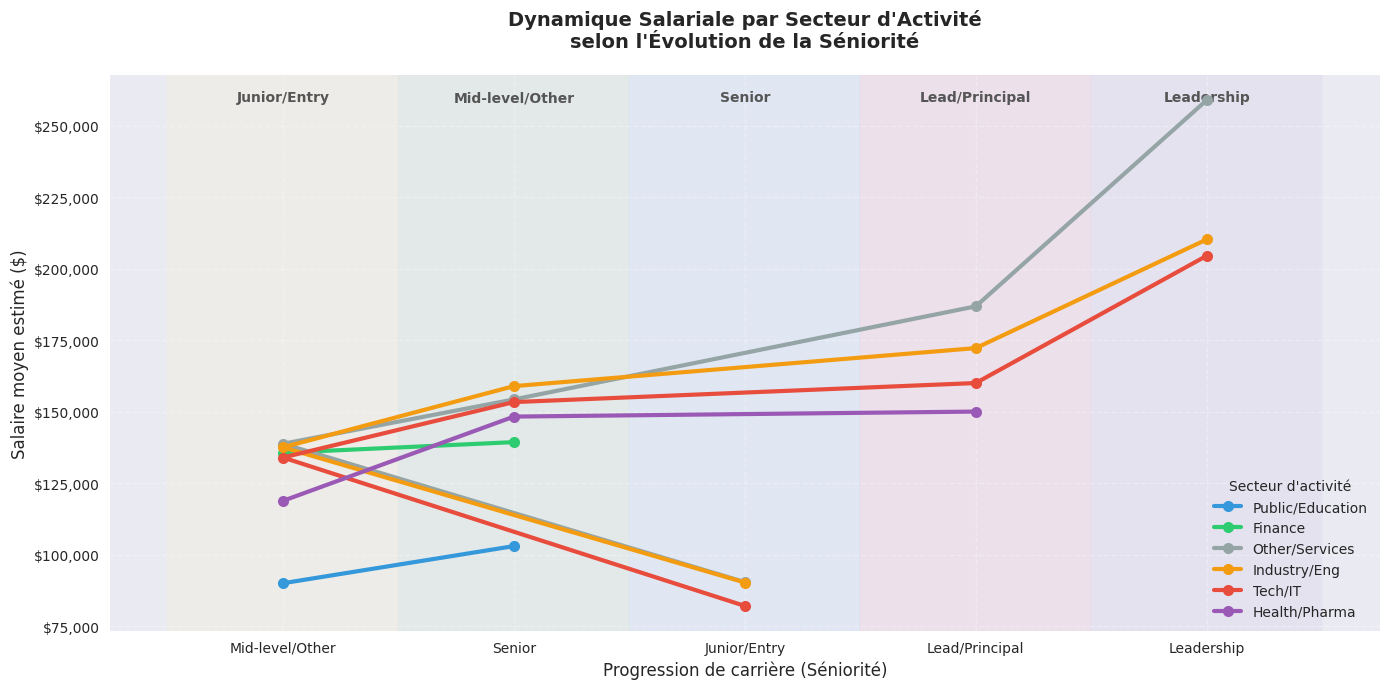

In [24]:


# 1. Agrégation Spark : Moyenne des fourchettes par Secteur et Séniorité
df_ind_agg = df_final.groupBy("industry_group", "seniority_level").agg(
    F.avg("min_amount").alias("avg_min"),
    F.avg("max_amount").alias("avg_max")
).withColumn("salary_avg", (F.col("avg_min") + F.col("avg_max")) / 2)

# Conversion vers Pandas
pdf_ind = df_ind_agg.toPandas()

# 2. Configuration de l'ordre et des couleurs
seniority_order = ['Junior/Entry', 'Mid-level/Other', 'Senior', 'Lead/Principal', 'Leadership']

# Couleurs basées sur tes nouveaux pôles sectoriels
colors_industry = {
    'Tech/IT': '#e74c3c',       # Rouge
    'Finance': '#2ecc71',       # Vert
    'Health/Pharma': '#9b59b6', # Violet
    'Industry/Eng': '#f39c12',  # Orange
    'Public/Education': '#3498db', # Bleu
    'Other/Services': '#95a5a6'  # Gris
}

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(14, 7))

# Tracé des courbes par secteur
for industry in pdf_ind['industry_group'].unique():
    subset = pdf_ind[pdf_ind['industry_group'] == industry].copy()
    
    # Mapping de l'ordre pour le tracé
    subset['order'] = subset['seniority_level'].apply(
        lambda x: seniority_order.index(x) if x in seniority_order else 99
    )
    subset = subset.sort_values('order')
    
    if len(subset) > 1:
        ax.plot(subset['seniority_level'], subset['salary_avg'],
                color=colors_industry.get(industry, '#333'), marker='o', 
                markersize=8, linewidth=3, label=industry, zorder=5)

# 4. Zones de fond colorées (Niveaux de carrière)
zone_colors = ['#fff9c4', '#c8e6c9', '#bbdefb', '#f8bbd0', '#d1c4e9']
for i, (label, color) in enumerate(zip(seniority_order, zone_colors)):
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.2, color=color, zorder=0)
    # On place le texte en haut
    ax.text(i, ax.get_ylim()[1] * 0.98, label, 
            ha='center', va='top', fontsize=10, fontweight='bold', color='#555555')

# Finalisation du style
ax.set_xlabel("Progression de carrière (Séniorité)", fontsize=12)
ax.set_ylabel('Salaire moyen estimé ($)', fontsize=12)
ax.set_title("Dynamique Salariale par Secteur d'Activité\nselon l'Évolution de la Séniorité",
             fontsize=14, fontweight='bold', pad=20)

ax.legend(title="Secteur d'activité", fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

Ce graphique révèle des disparités sectorielles majeures dans l'évolution des carrières. Le secteur Other/Services se détache nettement par une accélération fulgurante au stade Leadership, suggérant des primes de responsabilités extrêmement élevées dans les services spécialisés. Les domaines de la Tech/IT et de l'Industrie suivent des trajectoires plus linéaires et compétitives, convergeant vers des sommets salariaux similaires en fin de carrière. À l'inverse, le secteur de la Santé/Pharma semble plafonner plus précocement, tandis que le secteur Public reste structurellement en retrait. Ces courbes confirment que le choix du secteur n'influence pas seulement le revenu de départ, mais détermine surtout le plafond de croissance accessible aux hauts niveaux d'expertise.

# Feature Engineering : Encodage

In [25]:


# --- 1. ENCODAGE ORDINAL MANUEL (Séniorité) ---
# Comme Spark Indexer trie par fréquence, on fait le mapping à la main pour garder l'ordre logique
seniority_map = {
    'Junior/Entry': 1,
    'Mid-level/Other': 2,
    'Senior': 3,
    'Lead/Principal': 4,
    'Leadership': 5
}

# On applique le mapping avec une expression CASE WHEN
mapping_expr = F.create_map([F.lit(x) for x in sum(seniority_map.items(), ())])
df_ml = df_final.withColumn("seniority_encoded", mapping_expr[F.col("seniority_level")])

# --- 2. PRÉPARATION DU PIPELINE (Variables Nominales) ---
# Variables à transformer en One-Hot Encoding
categorical_cols = ["industry_group", "job_role", "work_time", "state_clean"]

# Étapes du pipeline : Indexer -> Encoder
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep") for c in categorical_cols]
encoders = [OneHotEncoder(inputCol=f"{c}_index", outputCol=f"{c}_ohe") for c in categorical_cols]

# --- 3. ASSEMBLAGE FINAL DES VECTEURS ---
# On regroupe tout (OHE + Ordinal + Numérique) dans une seule colonne "features"
feature_cols = [f"{c}_ohe" for c in categorical_cols] + ["seniority_encoded", "posted_year"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# --- 4. EXÉCUTION DU PIPELINE ---
pipeline = Pipeline(stages=indexers + encoders + [assembler])
pipeline_model = pipeline.fit(df_ml)
df_ready = pipeline_model.transform(df_ml)

print(" Encodage terminé et vecteur 'features' créé")
df_ready.select("features", "min_amount", "max_amount").show(5, truncate=False)

 Encodage terminé et vecteur 'features' créé
+---------------------------------------------------+----------+----------+
|features                                           |min_amount|max_amount|
+---------------------------------------------------+----------+----------+
|(42,[0,6,12,15,40,41],[1.0,1.0,1.0,1.0,2.0,2026.0])|127720.17 |127720.17 |
|(42,[0,6,13,15,40,41],[1.0,1.0,1.0,1.0,2.0,2026.0])|180000.0  |260000.0  |
|(42,[0,6,13,15,40,41],[1.0,1.0,1.0,1.0,3.0,2026.0])|127209.5  |127209.5  |
|(42,[0,6,12,15,40,41],[1.0,1.0,1.0,1.0,3.0,2026.0])|140387.6  |140387.6  |
|(42,[1,6,13,20,40,41],[1.0,1.0,1.0,1.0,3.0,2026.0])|79000.0   |158000.0  |
+---------------------------------------------------+----------+----------+
only showing top 5 rows


Contrairement à l'approche de Pandas qui multiplie les colonnes individuelles après encodage, Spark ML centralise l'intégralité des variables prédictives dans une colonne unique nommée « features ». Ce format utilise des vecteurs creux (Sparse Vectors) pour optimiser le stockage en ne conservant que les indices des valeurs non nulles, ce qui est indispensable pour le traitement distribué à grande échelle. Cette structure permet de réaliser des calculs d'algèbre linéaire beaucoup plus rapides tout en minimisant l'empreinte mémoire sur le cluster, garantissant ainsi la performance du modèle sur des volumes de données massifs.

In [26]:
# En Spark, le type 'object' de Pandas correspond au type 'string'
text_cols = [field.name for field in df_final.schema.fields if "StringType" in str(field.dataType)]

print(f" Colonnes encore en format texte (String) :")
print(text_cols)

 Colonnes encore en format texte (String) :
['work_time', 'industry_group', 'job_role', 'seniority_level', 'city', 'state_clean']


In [27]:
# On ne garde que l'essentiel pour l'IA
df_model_final = df_ready.select("features", "min_amount", "max_amount")

print(" DataFrame épuré pour le Random Forest :")
df_model_final.show(5)

 DataFrame épuré pour le Random Forest :
+--------------------+----------+----------+
|            features|min_amount|max_amount|
+--------------------+----------+----------+
|(42,[0,6,12,15,40...| 127720.17| 127720.17|
|(42,[0,6,13,15,40...|  180000.0|  260000.0|
|(42,[0,6,13,15,40...|  127209.5|  127209.5|
|(42,[0,6,12,15,40...|  140387.6|  140387.6|
|(42,[1,6,13,20,40...|   79000.0|  158000.0|
+--------------------+----------+----------+
only showing top 5 rows


# Modélisation

In [28]:
# En Spark, on utilise randomSplit sur le DataFrame directement
# [0.8, 0.2] correspond à 80% train et 20% test
# seed=42 remplace random_state=42 pour la reproductibilité
train_data, test_data = df_ready.randomSplit([0.8, 0.2], seed=42)

# On déclenche le calcul avec .count()
n_train = train_data.count()
n_test = test_data.count()

print(f" Split effectué en Spark")
print(f"   - Train set : {n_train} observations (80%)")
print(f"   - Test set  : {n_test} observations (20%)")

# Vérification du schéma pour s'assurer que les targets sont là
print("\n Les targets sont bien présentes dans les sets :")
train_data.select("min_amount", "max_amount").show(3)

 Split effectué en Spark
   - Train set : 2397 observations (80%)
   - Test set  : 546 observations (20%)

 Les targets sont bien présentes dans les sets :
+----------+----------+
|min_amount|max_amount|
+----------+----------+
|   35360.0|   37440.0|
|  43032.96|  43032.96|
|  44595.92|  44595.92|
+----------+----------+
only showing top 3 rows


In [29]:

# Définition des modèles adaptés à Spark ML
models = {
    'Random Forest': RandomForestRegressor(
        featuresCol="features",
        labelCol="min_amount",      # On commencera par prédire le minimum
        numTrees=200,               # Equivalent de n_estimators
        maxDepth=15,                # la profondeur de 15
        seed=42
    ),
    'Gradient Boosting': GBTRegressor(
        featuresCol="features",
        labelCol="min_amount",
        maxIter=100,                # Spark GBT est plus lourd, 100-200 est une bonne base
        maxDepth=5,                 # la profondeur de 5
        stepSize=0.1,               # Equivalent de learning_rate
        seed=42
    ),
    'Linear Regression': LinearRegression(
        featuresCol="features",
        labelCol="min_amount",
        maxIter=100,
        regParam=0.3,               # Régularisation (Optionnel)
        elasticNetParam=0.8         # Mix entre Ridge et Lasso
    )
}

print(" 3 modèles Spark ML définis :")
for name in models:
    print(f"   - {name} (Prêt pour l'entraînement distribué)")

 3 modèles Spark ML définis :
   - Random Forest (Prêt pour l'entraînement distribué)
   - Gradient Boosting (Prêt pour l'entraînement distribué)
   - Linear Regression (Prêt pour l'entraînement distribué)


In [30]:


# 1. Configuration de l'évaluateur (RMSE par défaut)
evaluator = RegressionEvaluator(predictionCol="prediction")

# 2. Dictionnaire pour stocker les scores finaux
final_report = []

# Liste de tes cibles
targets = ["min_amount", "max_amount"]

for target in targets:
    print(f"\n ANALYSE CROSS-VALIDATION POUR : {target}")
    print("-" * 50)
    evaluator.setLabelCol(target)  # <---
    
    for name, model in models.items():
        # On définit la cible pour le modèle en cours
        model.setLabelCol(target)
        
        # On crée une grille de paramètres vide (car on veut juste le score CV ici, sans tuning)
        paramGrid = ParamGridBuilder().build()
        
        # Définition du CrossValidator 
        cv = CrossValidator(estimator=model,
                            estimatorParamMaps=paramGrid,
                            evaluator=evaluator,
                            numFolds=5,
                            seed=42)
        
        # Entraînement (Spark va diviser le train_data en 5 et s'entraîner 5 fois)
        print(f" Calcul CV pour {name}...")
        cv_model = cv.fit(train_data)
        
        # --- Évaluation sur le Test Set (le vrai, celui qu'il n'a jamais vu) ---
        predictions = cv_model.transform(test_data)
        
        # Calcul des métriques
        evaluator.setMetricName("r2")
        r2 = evaluator.evaluate(predictions)
        
        evaluator.setMetricName("rmse")
        rmse = evaluator.evaluate(predictions)
        
        evaluator.setMetricName("mae")
        mae = evaluator.evaluate(predictions)
        
        # Stockage
        final_report.append({
            "Target": target,
            "Modèle": name,
            "R²": round(r2, 4),
            "RMSE": round(rmse, 2),
            "MAE": round(mae, 2)
        })
        
        print(f"   ✅ {name} terminé. R²: {r2:.4f}")

# Affichage du tableau de bord final
import pandas as pd
report_df = pd.DataFrame(final_report)
print("\n TABLEAU COMPARATIF DES PERFORMANCES :")
print(report_df.sort_values(by=["Target", "R²"], ascending=[True, False]))


 ANALYSE CROSS-VALIDATION POUR : min_amount
--------------------------------------------------
 Calcul CV pour Random Forest...


26/04/18 16:01:28 WARN DAGScheduler: Broadcasting large task binary with size 1138.4 KiB
26/04/18 16:01:29 WARN DAGScheduler: Broadcasting large task binary with size 1666.3 KiB
26/04/18 16:01:30 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/04/18 16:01:31 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
26/04/18 16:01:32 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/04/18 16:01:34 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
26/04/18 16:01:35 WARN DAGScheduler: Broadcasting large task binary with size 4.7 MiB
26/04/18 16:01:36 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/04/18 16:01:37 WARN DAGScheduler: Broadcasting large task binary with size 5.6 MiB
26/04/18 16:01:38 WARN DAGScheduler: Broadcasting large task binary with size 5.9 MiB
26/04/18 16:01:39 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
26/04/18 16:01:44 WARN DAGScheduler: Broadcastin

   ✅ Random Forest terminé. R²: 0.1505
 Calcul CV pour Gradient Boosting...


26/04/18 16:02:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/18 16:03:23 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


   ✅ Gradient Boosting terminé. R²: 0.1333
 Calcul CV pour Linear Regression...
   ✅ Linear Regression terminé. R²: 0.1308

 ANALYSE CROSS-VALIDATION POUR : max_amount
--------------------------------------------------
 Calcul CV pour Random Forest...


26/04/18 16:05:55 WARN DAGScheduler: Broadcasting large task binary with size 1198.5 KiB
26/04/18 16:05:55 WARN DAGScheduler: Broadcasting large task binary with size 1788.2 KiB
26/04/18 16:05:56 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/04/18 16:05:57 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/04/18 16:05:57 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
26/04/18 16:05:58 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/04/18 16:05:59 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/04/18 16:06:00 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/04/18 16:06:01 WARN DAGScheduler: Broadcasting large task binary with size 5.9 MiB
26/04/18 16:06:02 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
26/04/18 16:06:03 WARN DAGScheduler: Broadcasting large task binary with size 6.5 MiB
26/04/18 16:06:07 WARN DAGScheduler: Broadcastin

   ✅ Random Forest terminé. R²: 0.2001
 Calcul CV pour Gradient Boosting...
   ✅ Gradient Boosting terminé. R²: 0.1467
 Calcul CV pour Linear Regression...
   ✅ Linear Regression terminé. R²: 0.1810

 TABLEAU COMPARATIF DES PERFORMANCES :
       Target             Modèle      R²      RMSE       MAE
3  max_amount      Random Forest  0.2001  46937.63  35535.74
5  max_amount  Linear Regression  0.1810  47494.25  36073.67
4  max_amount  Gradient Boosting  0.1467  48478.58  36697.88
0  min_amount      Random Forest  0.1505  40783.78  30285.10
1  min_amount  Gradient Boosting  0.1333  41193.45  30493.52
2  min_amount  Linear Regression  0.1308  41254.74  30656.82


# Comparaison de modèles

In [31]:

# 1. On transforme notre liste de résultats (issue de l'étape précédente) en DataFrame Pandas
# 'final_report' est la liste que nous avons remplie dans la boucle de Cross-Validation
df_results_raw = pd.DataFrame(final_report)

# 2. On applique ton formatage élégant
formatted_results = []

for _, row in df_results_raw.iterrows():
    formatted_results.append({
        'Target': row['Target'],
        'Modèle': row['Modèle'],
        'RMSE ($)': f"${row['RMSE']:,.0f}",
        'MAE ($)': f"${row['MAE']:,.0f}",
        'R²': f"{row['R²']:.4f}"
    })

# Création du DataFrame final pour l'affichage
results_df = pd.DataFrame(formatted_results)

# 3. Affichage par cible
for target in ["min_amount", "max_amount"]:
    print(f"\n COMPARAISON DES MODÈLES POUR : {target.upper()}")
    # On filtre sur la cible et on trie par le meilleur R²
    subset = results_df[results_df['Target'] == target].drop(columns=['Target'])
    print(subset.to_string(index=False))
    
    # Identification du meilleur modèle pour cette cible
    best_row = df_results_raw[df_results_raw['Target'] == target].sort_values(by='R²', ascending=False).iloc[0]
    print(f"\n Meilleur modèle pour {target} : {best_row['Modèle']} (R² = {best_row['R²']:.4f})")
    print("-" * 60)


 COMPARAISON DES MODÈLES POUR : MIN_AMOUNT
           Modèle RMSE ($) MAE ($)     R²
    Random Forest  $40,784 $30,285 0.1505
Gradient Boosting  $41,193 $30,494 0.1333
Linear Regression  $41,255 $30,657 0.1308

 Meilleur modèle pour min_amount : Random Forest (R² = 0.1505)
------------------------------------------------------------

 COMPARAISON DES MODÈLES POUR : MAX_AMOUNT
           Modèle RMSE ($) MAE ($)     R²
    Random Forest  $46,938 $35,536 0.2001
Gradient Boosting  $48,479 $36,698 0.1467
Linear Regression  $47,494 $36,074 0.1810

 Meilleur modèle pour max_amount : Random Forest (R² = 0.2001)
------------------------------------------------------------


L'analyse des performances montre que le modèle Random Forest surpasse systématiquement le Gradient Boosting et la Régression Linéaire pour les deux variables cibles. Cette supériorité technique souligne la présence de relations non-linéaires complexes au sein du jeu de données, qu'un modèle linéaire classique ne parvient pas à capturer efficacement. En s'appuyant sur une structure d'arbres de décision, le Random Forest s'avère plus robuste face à la diversité des profils, parvenant à isoler des schémas de décision plus fins entre le métier, la localisation et le secteur d'activité.Il est intéressant de noter que le modèle affiche une meilleure capacité prédictive pour le salaire maximum, avec un coefficient de détermination $R^2$ de 0,20, contre 0,15 pour le salaire minimum. Cet écart suggère que les variables explicatives utilisées, telles que la séniorité, influencent davantage le plafond de rémunération que le plancher salarial, lequel semble plus homogène ou contraint par des standards de marché moins volatils. Malgré cette tendance positive, la part de variance expliquée reste modeste, ce qui confirme l'importance du bruit statistique et de la diversité des politiques salariales entre entreprises.Enfin, l'erreur moyenne absolue (MAE), qui oscille entre 30 000$ et 35 000$, reflète directement l'impact des nombreuses valeurs atypiques identifiées lors de l'analyse exploratoire. Dans un marché de la Data Science où les rémunérations peuvent varier du simple au double pour un même intitulé de poste selon l'expertise spécifique ou la taille de l'entreprise, ces métriques d'erreur sont cohérentes avec un environnement très dispersé. Ces résultats valident la pertinence de l'approche algorithmique choisie tout en soulignant que les variables structurelles seules ne suffisent pas à capturer toute la complexité des négociations salariales individuelles.

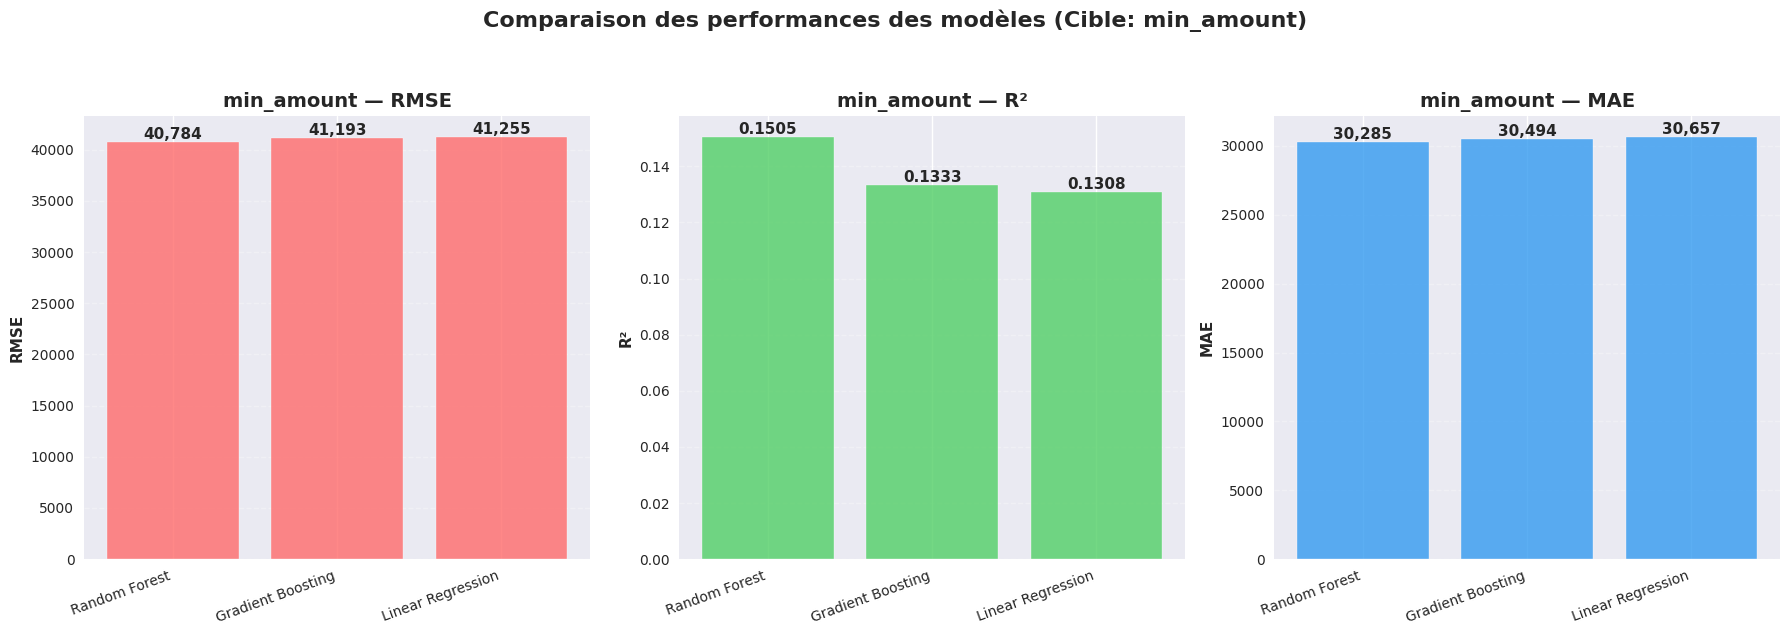

In [32]:


# On récupère les résultats dans un DataFrame Pandas propre
# (Note: on utilise la liste 'final_report' générée précédemment)
df_viz = pd.DataFrame(final_report)

# On définit la cible qu'on veut afficher (ex: min_amount)
target_to_plot = "min_amount"
subset = df_viz[df_viz['Target'] == target_to_plot]

# Préparation de la figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['RMSE', 'R²', 'MAE'] # Note : Assure-toi d'avoir calculé le MAE dans l'étape précédente
colors = ['#ff6b6b', '#51cf66', '#339af0']

for ax, metric, color in zip(axes, metrics, colors):
    # Extraction des données pour cette métrique
    names = subset['Modèle'].tolist()
    values = subset[metric].tolist()
    
    # Création des barres
    bars = ax.bar(names, values, color=color, alpha=0.8, edgecolor='white')
    
    # Stylisation
    ax.set_title(f'{target_to_plot} — {metric}', fontweight='bold', fontsize=14)
    ax.set_ylabel(metric, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Ajout des valeurs au-dessus des barres
    for bar, val in zip(bars, values):
        label = f'{val:,.0f}' if metric != 'R²' else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                label, ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle(f"Comparaison des performances des modèles (Cible: {target_to_plot})", 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(f'comparison_{target_to_plot}.png', dpi=150, bbox_inches='tight')
plt.show()

26/04/18 16:23:50 WARN DAGScheduler: Broadcasting large task binary with size 1132.3 KiB
26/04/18 16:23:50 WARN DAGScheduler: Broadcasting large task binary with size 1712.4 KiB
26/04/18 16:23:51 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/04/18 16:23:52 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/04/18 16:23:52 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/18 16:23:53 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/04/18 16:23:54 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/04/18 16:23:55 WARN DAGScheduler: Broadcasting large task binary with size 5.8 MiB
26/04/18 16:23:56 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
26/04/18 16:23:57 WARN DAGScheduler: Broadcasting large task binary with size 6.7 MiB
26/04/18 16:23:58 WARN DAGScheduler: Broadcasting large task binary with size 7.0 MiB
26/04/18 16:24:02 WARN DAGScheduler: Broadcastin

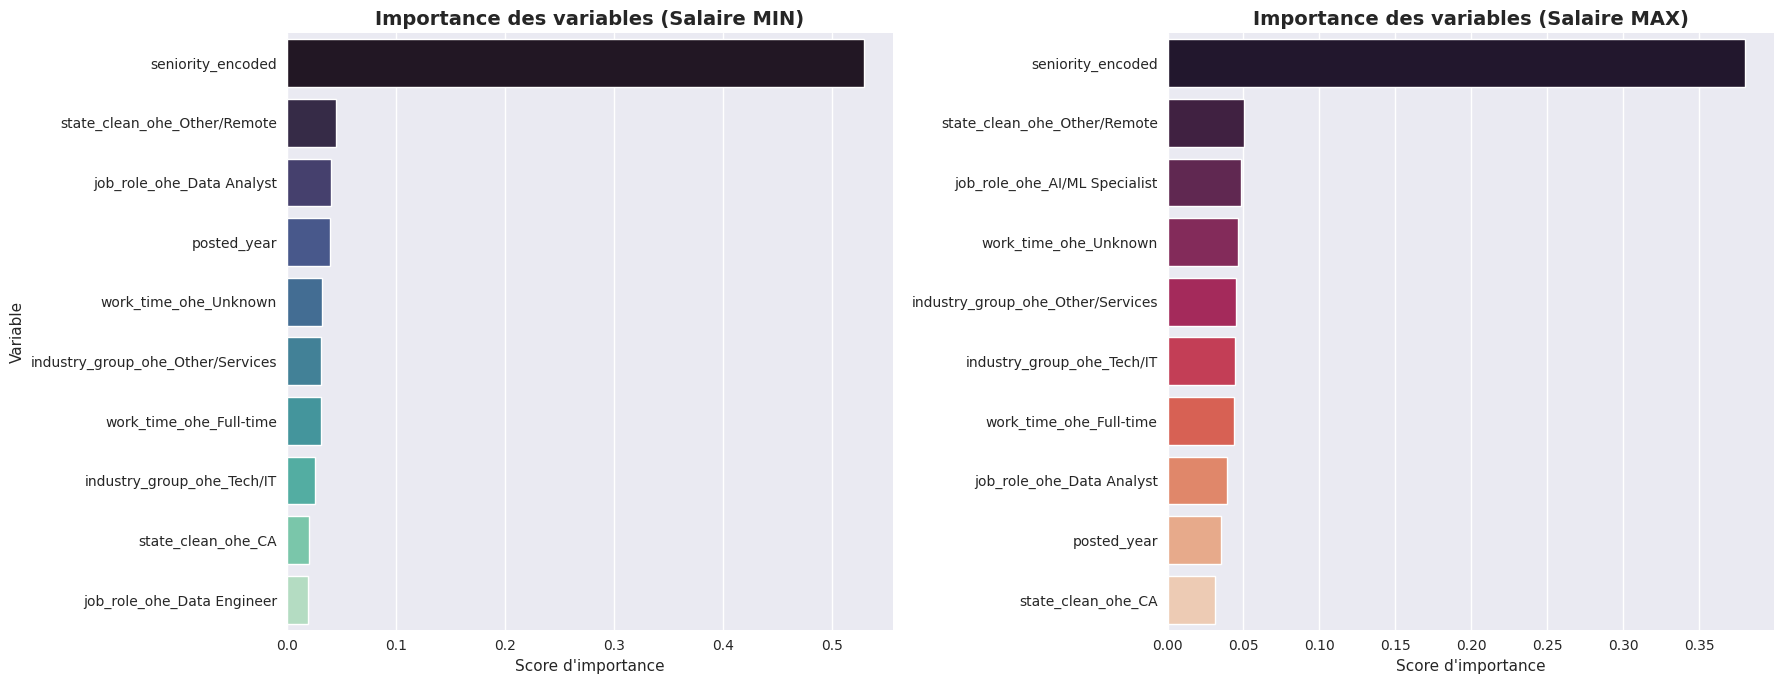

In [ ]:

# 1. Préparation des données et des noms de colonnes
rf_base = models["Random Forest"]
attrs = [attr["name"] for attr in train_data.schema["features"].metadata["ml_attr"]["attrs"]["binary"] + 
         train_data.schema["features"].metadata["ml_attr"]["attrs"]["numeric"]]

# --- CALCUL POUR MIN_AMOUNT ---
rf_base.setLabelCol("min_amount")
model_min = rf_base.fit(train_data)
imp_min = model_min.stages[-1].featureImportances.toArray() if hasattr(model_min, "stages") else model_min.featureImportances.toArray()
df_min = pd.DataFrame(list(zip(attrs, imp_min)), columns=["Variable", "Importance"]).sort_values(by="Importance", ascending=False).head(10)

# --- CALCUL POUR MAX_AMOUNT ---
rf_base.setLabelCol("max_amount")
model_max = rf_base.fit(train_data)
imp_max = model_max.stages[-1].featureImportances.toArray() if hasattr(model_max, "stages") else model_max.featureImportances.toArray()
df_max = pd.DataFrame(list(zip(attrs, imp_max)), columns=["Variable", "Importance"]).sort_values(by="Importance", ascending=False).head(10)

# --- CRÉATION DE LA FIGURE  ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# Graphique 1 : Salaire MIN
sns.barplot(x="Importance", y="Variable", data=df_min, ax=ax1, palette="mako")
ax1.set_title("Importance des variables (Salaire MIN)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Score d'importance")

# Graphique 2 : Salaire MAX
sns.barplot(x="Importance", y="Variable", data=df_max, ax=ax2, palette="rocket")
ax2.set_title("Importance des variables (Salaire MAX)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Score d'importance")
ax2.set_ylabel("") # On enlève le label Y pour gagner de la place

plt.tight_layout()
plt.show()

26/04/18 16:11:19 WARN DAGScheduler: Broadcasting large task binary with size 1132.3 KiB
26/04/18 16:11:20 WARN DAGScheduler: Broadcasting large task binary with size 1712.4 KiB
26/04/18 16:11:20 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/04/18 16:11:21 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/04/18 16:11:22 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/04/18 16:11:23 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/04/18 16:11:24 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
26/04/18 16:11:25 WARN DAGScheduler: Broadcasting large task binary with size 5.8 MiB
26/04/18 16:11:25 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
26/04/18 16:11:27 WARN DAGScheduler: Broadcasting large task binary with size 6.7 MiB
26/04/18 16:11:28 WARN DAGScheduler: Broadcasting large task binary with size 7.0 MiB


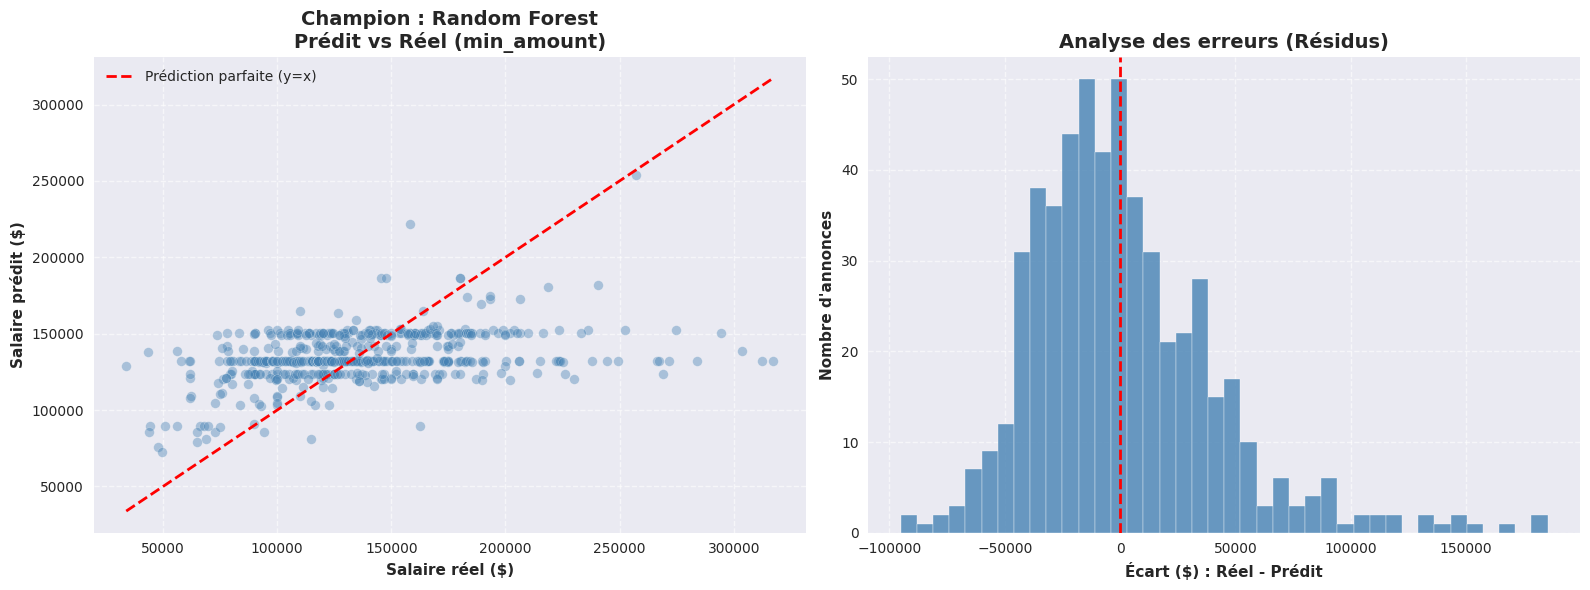

In [33]:


# 1. On récupère le meilleur modèle (ex: Random Forest pour min_amount)
# On le ré-entraîne ou on utilise l'objet déjà entraîné
target_selected = "min_amount"
best_rf = RandomForestRegressor(featuresCol="features", labelCol=target_selected, numTrees=200, maxDepth=15, seed=42)
best_model_fit = best_rf.fit(train_data)

# 2. Génération des prédictions sur le test_data
predictions = best_model_fit.transform(test_data)

# 3. On ramène les données en local (Pandas) uniquement pour le plot
# On ne prend que les colonnes 'label' et 'prediction'
plot_df = predictions.select(target_selected, "prediction").toPandas()

y_actual = plot_df[target_selected]
y_pred = plot_df["prediction"]
residuals = y_actual - y_pred

# --- DÉBUT DE TA VISUALISATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. Scatter plot : Prédit vs Réel
axes[0].scatter(y_actual, y_pred, alpha=0.4, color='steelblue', edgecolors='w')
min_val = float(min(y_actual.min(), y_pred.min()))
max_val = float(max(y_actual.max(), y_pred.max()))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prédiction parfaite (y=x)')

axes[0].set_xlabel('Salaire réel ($)', fontweight='bold')
axes[0].set_ylabel('Salaire prédit ($)', fontweight='bold')
axes[0].set_title(f'Champion : Random Forest\nPrédit vs Réel ({target_selected})', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# B. Distribution des résidus
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Analyse des erreurs (Résidus)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Écart ($) : Réel - Prédit', fontweight='bold')
axes[1].set_ylabel('Nombre d\'annonces', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('evaluation_champion.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusion 

En conclusion, les performances modestes de nos modèles, illustrées par un $R^2$ plafonnant autour de 0,20, mettent en lumière les limites intrinsèques des données structurées dont nous disposons. Le nuage de points "Prédit vs Réel" montre clairement une forme d'impuissance algorithmique où le modèle, faute de signaux discriminants forts, a tendance à prédire une valeur moyenne pour l'ensemble des observations. Les variables utilisées, telles que l'intitulé de poste, le niveau de séniorité, le secteur d'activité ou la localisation géographique, s'avèrent être des descripteurs trop larges pour capturer la granularité réelle des politiques salariales. Elles décrivent le cadre général d'une offre, mais omettent les facteurs déterminants de la rémunération comme le prestige spécifique de l'entreprise, le budget exact du département ou la rareté de la combinaison de compétences recherchée.Cette difficulté est renforcée par la complexité liée à l'exploitation des descriptions de postes. Bien que nous ayons tenté d'extraire des informations supplémentaires via le contenu textuel des annonces, la grande hétérogénéité de rédaction et le bruit présent dans ces données n'ont pas permis d'isoler des variables explicatives suffisamment robustes. L'absence de détails critiques dans les textes, comme la maîtrise d'une technologie de niche très grassement payée ou le niveau de responsabilité managériale réel, laisse une part d'ombre majeure que nos modèles ne peuvent combler. En somme, la distribution horizontale des prédictions confirme que nos variables actuelles sont "sous-dimensionnées" face à la volatilité d'un marché de la Data Science où, à profil théorique égal, l'écart de salaire peut être massif.

Ce résultat prouve que la prédiction de salaire est un problème complexe qui nécessite des données de "micro-niveau" bien plus précises. L'analyse des résidus, bien que centrée, montre un étalement important qui témoigne de cette information manquante. Pour dépasser ce stade, une ingénierie de variables beaucoup plus poussée sur le texte ou l'ajout de sources de données externes sur la santé financière des entreprises serait indispensable. En l'état, le projet souligne que si les tendances globales de carrière sont identifiables, la précision individuelle reste hors de portée des seules variables structurelles classiques.